<a href="https://colab.research.google.com/github/Jackline-Jebet/Big-Data---Machine-Learning/blob/main/Big_Data_Analytics_using_ML_Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import required PySpark libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, explode, split, lower, regexp_replace, udf, collect_list
from pyspark.ml.feature import Word2Vec, StopWordsRemover, VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, ClusteringEvaluator
from pyspark.sql.types import StringType
import pyspark.sql.functions as F
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.functions import vector_to_array
from pyspark.sql.types import ArrayType, DoubleType

# Import libraries for visualization and dimensionality reduction
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
import pandas as pd


In [ ]:
# Initialize Spark session
spark = SparkSession.builder.appName("Task1_Word2Vec_ML").getOrCreate()

In [ ]:
# Step 1: Load the 20 Newsgroups dataset
# Using scikit-learn to fetch the dataset, then convert to PySpark DataFrame
from sklearn.datasets import fetch_20newsgroups
categories = ['rec.sport.baseball', 'sci.med', 'comp.graphics', 'talk.politics.guns']
newsgroups = fetch_20newsgroups(subset='all', categories=categories, remove=('headers', 'footers', 'quotes'))
# Explicitly cast the label (newsgroups.target) to int
data = [(text, int(category)) for text, category in zip(newsgroups.data, newsgroups.target)]
df = spark.createDataFrame(data, ["text", "label"])
df.show(10)

+--------------------+-----+
|                text|label|
+--------------------+-----+
|\nA book that I c...|    0|
|\nHaving thought ...|    0|
|I am looking for ...|    0|
|\n       The San ...|    3|
|Anyone who worrie...|    3|
|he\n\n\n     Are ...|    0|
|\nThe best progra...|    0|
|\nMy daughter has...|    2|
|\n\n\n\n\nI don't...|    3|
|I need some infor...|    2|
+--------------------+-----+
only showing top 10 rows



In [ ]:
# Step 2: Preprocess the text data
# Clean text: lowercase, remove punctuation, and split into words
df_clean = df.withColumn("text", lower(col("text")))
df_clean = df_clean.withColumn("text", regexp_replace(col("text"), "[^a-zA-Z\s]", ""))
df_words = df_clean.withColumn("words", split(col("text"), "\s+"))
print(df_words.show(10))

+--------------------+-----+--------------------+
|                text|label|               words|
+--------------------+-----+--------------------+
|\na book that i c...|    0|[, a, book, that,...|
|\nhaving thought ...|    0|[, having, though...|
|i am looking for ...|    0|[i, am, looking, ...|
|\n       the san ...|    3|[, the, san, jose...|
|anyone who worrie...|    3|[anyone, who, wor...|
|he\n\n\n     are ...|    0|[he, are, we, tal...|
|\nthe best progra...|    0|[, the, best, pro...|
|\nmy daughter has...|    2|[, my, daughter, ...|
|\n\n\n\n\ni dont ...|    3|[, i, dont, think...|
|i need some infor...|    2|[i, need, some, i...|
+--------------------+-----+--------------------+
only showing top 10 rows

None


In [ ]:
# Remove stop words
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
df_filtered = remover.transform(df_words)
print(df_filtered.show(10))

+--------------------+-----+--------------------+--------------------+
|                text|label|               words|      filtered_words|
+--------------------+-----+--------------------+--------------------+
|\na book that i c...|    0|[, a, book, that,...|[, book, somewhat...|
|\nhaving thought ...|    0|[, having, though...|[, thought, dont,...|
|i am looking for ...|    0|[i, am, looking, ...|[looking, sharewa...|
|\n       the san ...|    3|[, the, san, jose...|[, san, jose, mer...|
|anyone who worrie...|    3|[anyone, who, wor...|[anyone, worries,...|
|he\n\n\n     are ...|    0|[he, are, we, tal...|[talking, colorvi...|
|\nthe best progra...|    0|[, the, best, pro...|[, best, program,...|
|\nmy daughter has...|    2|[, my, daughter, ...|[, daughter, epil...|
|\n\n\n\n\ni dont ...|    3|[, i, dont, think...|[, dont, think, o...|
|i need some infor...|    2|[i, need, some, i...|[need, informatio...|
+--------------------+-----+--------------------+--------------------+
only s

In [ ]:
# Step 3: Train Word2Vec model
word2vec = Word2Vec(vectorSize=100, minCount=5, inputCol="filtered_words", outputCol="embeddings")
w2v_model = word2vec.fit(df_filtered)
df_embeddings = w2v_model.transform(df_filtered)
print(df_embeddings.show(10))

+--------------------+-----+--------------------+--------------------+--------------------+
|                text|label|               words|      filtered_words|          embeddings|
+--------------------+-----+--------------------+--------------------+--------------------+
|\na book that i c...|    0|[, a, book, that,...|[, book, somewhat...|[-0.0643072475989...|
|\nhaving thought ...|    0|[, having, though...|[, thought, dont,...|[-0.0114066041314...|
|i am looking for ...|    0|[i, am, looking, ...|[looking, sharewa...|[-0.0688034911189...|
|\n       the san ...|    3|[, the, san, jose...|[, san, jose, mer...|[0.05398411684754...|
|anyone who worrie...|    3|[anyone, who, wor...|[anyone, worries,...|[0.01719717177647...|
|he\n\n\n     are ...|    0|[he, are, we, tal...|[talking, colorvi...|[-0.0500475896748...|
|\nthe best progra...|    0|[, the, best, pro...|[, best, program,...|[-0.0520361891311...|
|\nmy daughter has...|    2|[, my, daughter, ...|[, daughter, epil...|[0.0101980

In [ ]:
# Step 4: Nearest Neighbor Analysis
# Find synonyms for a sample word (e.g., "baseball")
synonyms = w2v_model.findSynonyms("baseball", 5)
print("Nearest neighbors for 'baseball':")
synonyms.show()

Nearest neighbors for 'baseball':
+------+------------------+
|  word|        similarity|
+------+------------------+
| stats|0.9362257122993469|
|  wins|0.9132064580917358|
|   win|0.9086406826972961|
| pitch|0.9062374830245972|
|season|0.9058719873428345|
+------+------------------+



In [ ]:
# Step 5: Prepare document-level embeddings for classification and clustering
# Convert vector to array
df_array = df_embeddings.withColumn("embedding_array", vector_to_array("embeddings"))

# Group by document and collect all word vectors
df_grouped = df_array.groupBy("label", "text") \
    .agg(collect_list("embedding_array").alias("embedding_list"))

In [ ]:
# UDF to compute average vector
def average_vectors(vectors):
    if not vectors:
        return []
    dim = len(vectors[0])
    result = [0.0] * dim
    for vec in vectors:
        for i in range(dim):
            result[i] += vec[i]
    return [x / len(vectors) for x in result]

avg_vector_udf = udf(average_vectors, ArrayType(DoubleType()))

In [ ]:
# Apply UDF to get document-level embedding
df_doc_embeddings = df_grouped.withColumn("doc_embeddings", avg_vector_udf("embedding_list"))
print(df_doc_embeddings.show(5))

+-----+--------------------+--------------------+--------------------+
|label|                text|      embedding_list|      doc_embeddings|
+-----+--------------------+--------------------+--------------------+
|    0|\thave you checke...|[[-0.018330955146...|[-0.0183309551461...|
|    0|\ti am unable to ...|[[-0.037118856728...|[-0.0371188567288...|
|    0|\ti heard that th...|[[-0.050565463352...|[-0.0505654633528...|
|    0|\tim looking for ...|[[-0.057433867012...|[-0.0574338670121...|
|    0|\tnot really i th...|[[-0.042262493446...|[-0.0422624934464...|
+-----+--------------------+--------------------+--------------------+
only showing top 5 rows

None


In [ ]:
# Map labels to numeric values for classification
categories_loaded = newsgroups.target_names
label_map = {cat: idx for idx, cat in enumerate(categories_loaded)}  # Map category name to integer
# Create a UDF to map category names to numeric labels
map_label_udf = udf(lambda x: float(label_map[x]), "double")
print("Label Map (category name to integer):", label_map)


Label Map (category name to integer): {'comp.graphics': 0, 'rec.sport.baseball': 1, 'sci.med': 2, 'talk.politics.guns': 3}


In [ ]:
# Apply the UDF to convert label column to numeric
df_doc_embeddings = df_doc_embeddings.withColumn("label_numeric", col("label").cast("double"))
df_doc_embeddings.select("label", "label_numeric").show(10)

+-----+-------------+
|label|label_numeric|
+-----+-------------+
|    2|          2.0|
|    2|          2.0|
|    3|          3.0|
|    1|          1.0|
|    3|          3.0|
|    3|          3.0|
|    2|          2.0|
|    2|          2.0|
|    1|          1.0|
|    3|          3.0|
+-----+-------------+
only showing top 10 rows



In [ ]:
#  Convert doc_embeddings to VectorUDT
to_vector = udf(lambda x: Vectors.dense(x), VectorUDT())
df_doc_embeddings = df_doc_embeddings.withColumn("doc_embeddings", to_vector(df_doc_embeddings["doc_embeddings"]))

In [ ]:
# Step 6: Multi-Class Classifier (Logistic Regression)
# Split data into training and test sets
train, test = df_doc_embeddings.randomSplit([0.8, 0.2], seed=42)

In [ ]:
# Train Logistic Regression model
lr = LogisticRegression(featuresCol="doc_embeddings", labelCol="label_numeric", maxIter=10)
lr_model = lr.fit(train)

In [ ]:
# Make predictions
predictions = lr_model.transform(test)
predictions.show(5)

+-----+--------------------+--------------------+--------------------+-------------+--------------------+--------------------+----------+
|label|                text|      embedding_list|      doc_embeddings|label_numeric|       rawPrediction|         probability|prediction|
+-----+--------------------+--------------------+--------------------+-------------+--------------------+--------------------+----------+
|    0|\ti heard that th...|[[-0.050565463352...|[-0.0505654633528...|          0.0|[5.68236951170726...|[0.99645617089953...|       0.0|
|    0|\n\ti got the uni...|[[-0.045134694516...|[-0.0451346945168...|          0.0|[5.62827872159875...|[0.99501866678144...|       0.0|
|    0|\n\tthis happens ...|[[-0.047255304521...|[-0.0472553045211...|          0.0|[8.05748120288555...|[0.99993167457523...|       0.0|
|    0|\n\n\tthe newspap...|[[-0.048733996212...|[-0.0487339962128...|          0.0|[1.26033502785968...|[0.41286948755924...|       0.0|
|    0|\n\n\n\n\nfinding...|[[-0.0

In [ ]:
# Evaluate classifier
evaluator = MulticlassClassificationEvaluator(labelCol="label_numeric", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print(f"Classifier Accuracy: {accuracy}")

Classifier Accuracy: 0.8628005657708628


In [ ]:
# Compute F1-score
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label_numeric", predictionCol="prediction", metricName="f1")
f1_score = evaluator_f1.evaluate(predictions)
print(f"Classifier F1-Score: {f1_score}")

Classifier F1-Score: 0.8630667142079116


In [ ]:
# Step 7: Clustering (K-Means)
# Train K-Means model
kmeans = KMeans(featuresCol="doc_embeddings", k=4, seed=42)
kmeans_model = kmeans.fit(df_doc_embeddings)
clusters = kmeans_model.transform(df_doc_embeddings)

In [ ]:
# Evaluate clustering
evaluator_cluster = ClusteringEvaluator(featuresCol="doc_embeddings", predictionCol="prediction")
silhouette = evaluator_cluster.evaluate(clusters)
print(f"Clustering Silhouette Score: {silhouette}")

Clustering Silhouette Score: 0.3518486497918732


In [ ]:
# Step 8: Visualizations
# Convert embeddings to Pandas for visualization
embeddings_pd = df_doc_embeddings.select("label", "label_numeric", "doc_embeddings").toPandas()
embeddings_array = np.array([row.doc_embeddings.toArray() for row in embeddings_pd.itertuples(index=False)])

In [ ]:
# t-SNE for embedding visualization
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(embeddings_array)

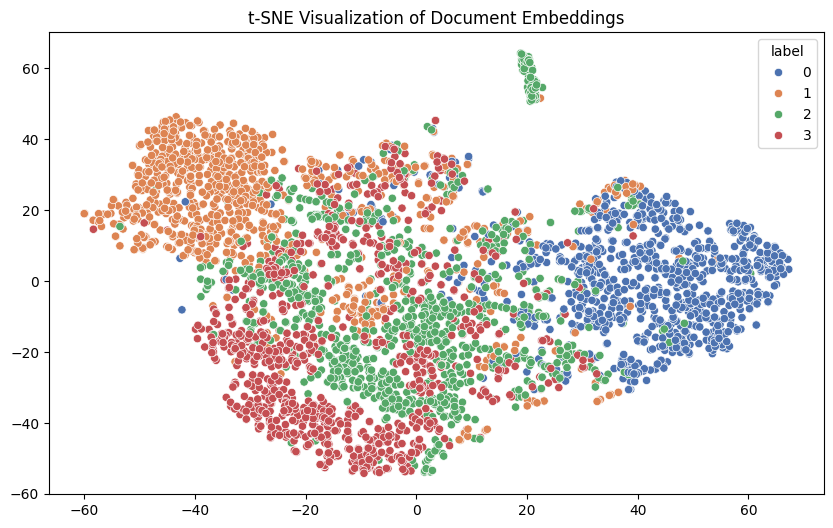

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot t-SNE
plt.figure(figsize=(10, 6))
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], hue=embeddings_pd["label"], palette="deep")
plt.title("t-SNE Visualization of Document Embeddings")
plt.show()
plt.savefig("t-SNE Visualization.png")


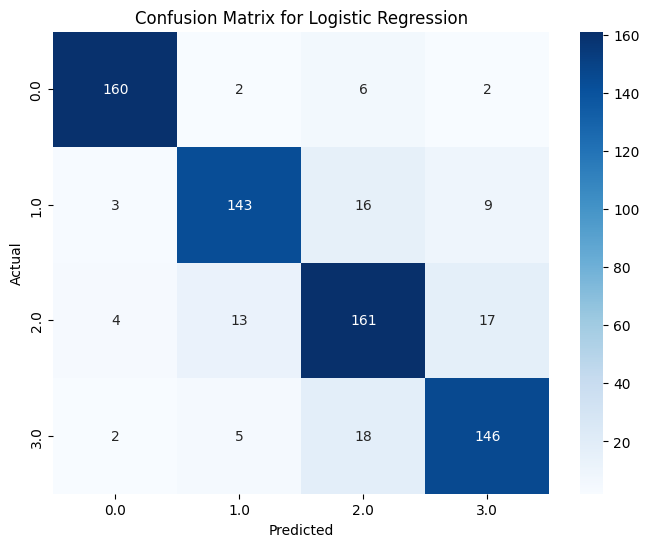

<Figure size 640x480 with 0 Axes>

In [ ]:
# Confusion matrix for classifier
cm = predictions.groupBy("label_numeric", "prediction").count().toPandas()
cm_pivot = cm.pivot(index="label_numeric", columns="prediction", values="count").fillna(0)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_pivot, annot=True, fmt="g", cmap="Blues")
plt.title("Confusion Matrix for Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
plt.savefig("confusion_matrix.png")

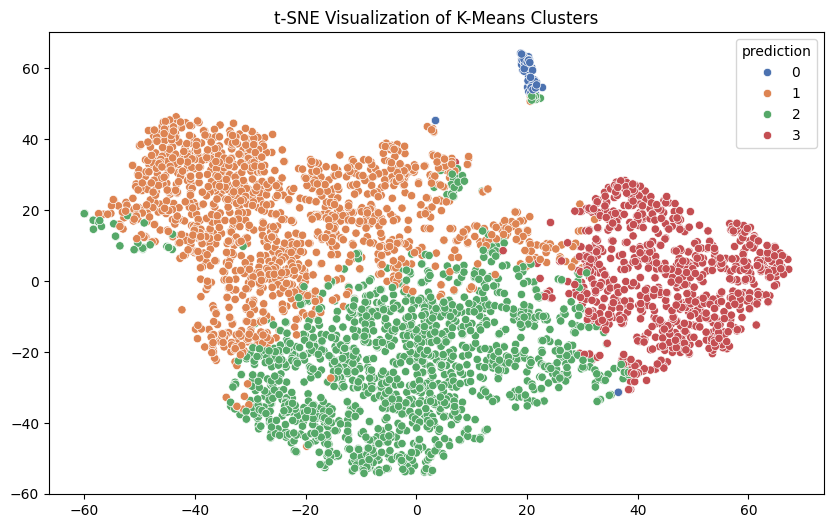

<Figure size 640x480 with 0 Axes>

In [ ]:
# Cluster visualization
clusters_pd = clusters.select("doc_embeddings", "prediction").toPandas()
clusters_array = np.array([row.doc_embeddings.toArray() for row in clusters_pd.itertuples(index=False)])
tsne_clusters = tsne.fit_transform(clusters_array)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=tsne_clusters[:, 0], y=tsne_clusters[:, 1], hue=clusters_pd["prediction"], palette="deep")
plt.title("t-SNE Visualization of K-Means Clusters")
plt.show()
plt.savefig("kmeans_clusters.png")


In [ ]:
spark.stop()